<a href="https://colab.research.google.com/github/AnisaAl/recipe-traffic/blob/main/data_science_process_steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Process Steps

Tasty Bytes was founded in 2020 in the midst of the Covid Pandemic. The world wanted
inspiration so we decided to provide it. We started life as a search engine for recipes, helping
people to find ways to use up the limited supplies they had at home.
Now, over two years on, we are a fully fledged business. For a monthly subscription we will put
together a full meal plan to ensure you and your family are getting a healthy, balanced diet
whatever your budget. Subscribe to our premium plan and we will also deliver the ingredients
to your door.

**The Product Team's request to Data Science Team**

They want to predict which recipes will be popular 80% of the time and minimize the chance of showing unpopular recipes.

Product Team is responsible for choosing which recipes to display on the
homepage each day, so they ask if the Data Science Team can help them choose which recipes to display on the home page.
At the moment, they choose the favorite recipe from a selection and display that on the home page. They have noticed that traffic to the rest of the website goes up by as much as 40% if they pick a popular recipe. But they don’t know how to decide if a recipe will be popular. More traffic
means more subscriptions so this is really important to the company.
Can Data Science team:
- Predict which recipes will lead to high traffic?
- Correctly predict high traffic recipes 80% of the time?

Don’t forget to double check the data really does match, it might not.

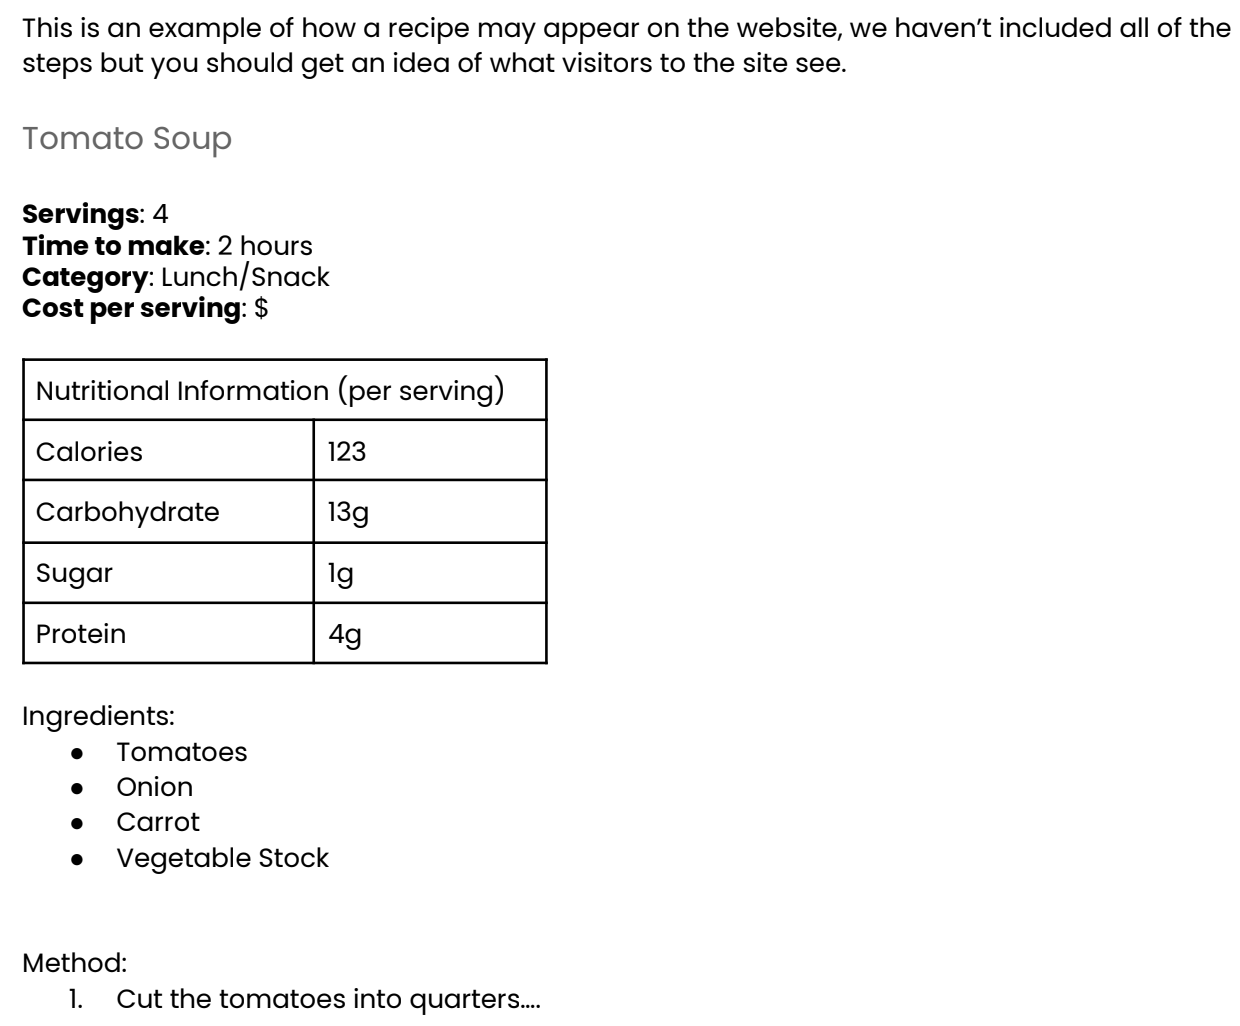

###Data Information
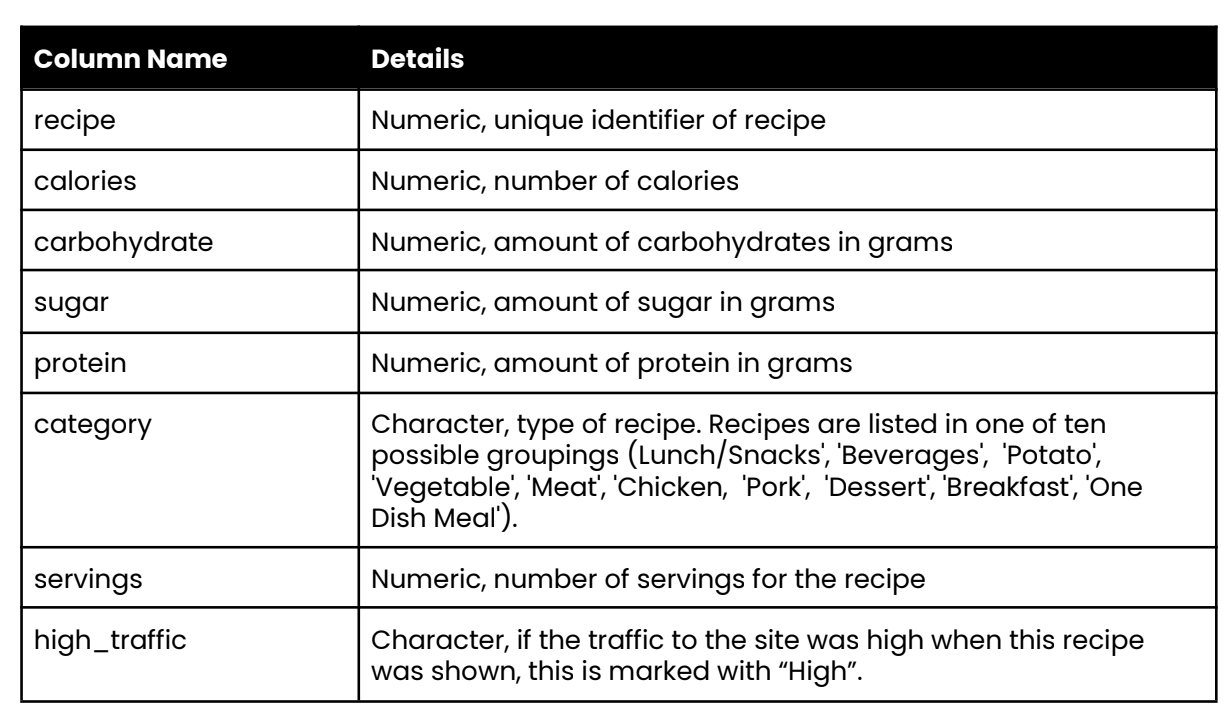

## Step 1 - Problem Formulation and Data Cleaning & Validation

Problem Formulation:
Predict which recipes will be popular 80% of the time and minimize the chance of showing unpopular recipes.

Business concerns:
- Predict which recipes will lead to high traffic? Meaning it might be popular.
- Correctly predict high traffic recipes 80% of the time - model accuracy >= 80%
- Minimize the chance of showing unpopular recipes
- Recommendations
- More traffic means more subscriptions so this is really important to the company.

Let's have a look at our data!

In [ ]:
# Setup - Importing the necessary libraries and the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("sample_data/recipe_site_traffic_2212.csv",index_col="recipe")
df.head(5)

In [ ]:
df.dtypes

### Dealing with types

There are 3 column types that we need to convert:
- servings should be Numeric
- high_traffic and category should be string

Checking servings column has only numerical values:

In [ ]:
# making sure it has only numerical values
print(df.servings.value_counts())

Removing the texts from the servings column and checking its type

In [ ]:
# removing the text from the last 2
df.servings = df.servings.str.slice(0,1)
print(df.servings.str.strip().value_counts())

In [ ]:
df.servings = df.servings.astype(int)

Making sure category and high_traffic columns are strings

In [ ]:
df.high_traffic = df.high_traffic.astype(str)
df.category = df.category.astype(str)
# to check if class is string
df.category.map(type).unique()

In [ ]:
df.high_traffic.map(type).unique()

### Looking out for duplicated recipes

In [ ]:
df.index.duplicated().sum()

### Dealing with categorical features

Recipes are listed in one of ten possible groupings:
'Lunch/Snacks', 'Beverages', 'Potato', 'Vegetable', 'Meat', 'Chicken, 'Pork', 'Dessert', 'Breakfast', 'One
Dish Meal'.

Let's check if there are other categories or misspelled ones.

In [ ]:
# checking values of "category" category
print(df.category.value_counts())

There seems to be an additional category called Chicken Breast and since it is closer to the Chicken category, then we replace its name with the 'Chicken' category and now this category will include a higher number of recipes as seen below:

In [ ]:
# merging Chicken Breast under Chicken category
df.category = df.category.replace({'Chicken Breast':'Chicken'})

In [ ]:
print(df.category.value_counts())

### Handling missing values

Let's check the values of our target variable!

In [ ]:
print(df.high_traffic.value_counts())

It seems like its values are either High for high traffic or missing values, which indicate no high traffic. It also seems that there are more recipes giving high traffic than low traffic. Since this is a string, we do not have to consider it as a missing value, so we are good to go.

Checking the missing values

In [ ]:
print(df.isna().sum())

Checking if missing values are on the same indices for all these four columns and then filtering the DataFrame to only show these rows and the columns of interest.

In [ ]:
# Check if missing values are on the same indices for all four column
columns_of_interest = ['calories', 'carbohydrate', 'sugar', 'protein']
same_indices = df[columns_of_interest].isnull().all(axis=1)

# Filter the DataFrame to only show these rows and the columns of interest
df_same_indices = df.loc[same_indices, columns_of_interest]

print(df_same_indices.shape)

Since the missing values seem to happen for the same recipes and since the other values are significant to us, then we can replace the missing values with the mean of the column so we would avoid causing any changes to the feature.

In [ ]:
# replacing missing values with mean
for col in columns_of_interest:
    mean_value = df[col].mean().round(2)
    df[col].fillna(mean_value, inplace=True)

assert df[columns_of_interest].isna().sum().sum() == 0, "There are still missing values in these columns"

Using an assertion, we can see that there is no error "There are still missing values in these columns" generated after dealing with the missing values.

### Data Validation

In order to validate the calories column, we first need to validate the sugar column. Sugar is a carbohydrate, therefore it should be contained in the carbohydrate grams, which means that we need to validate that the number of sugar grams is smaller than that of carbs.

In [ ]:
check_sugar = df.sugar <= df.carbohydrate
print(df[~check_sugar].shape)

There seems to be a lot of rows like this, therefore instead of moving them, the better approach would be to update the carbohydrate column with the sugar column, because that is the minimum grams of carbs a meal can have.

In [ ]:
df.loc[df.carbohydrate <= df.sugar, 'carbohydrate'] = df.sugar
assert df.carbohydrate.any() >= df.sugar.any()

The assertion tells us there are no more carbs higher than sugar values.

**Validating Calories**

Now it is needed that we validate the calories column by checking the sum of calories of carbohydrates, proteins, fats and other nutritional values. Since sugar is already a carbohydrate, it is already included in the calculation, but since we already are missing the information about the fat, which is an important part of measuring the calories, then we will just validate that the calories column is not smaller than the total sum of calories of carbs and proteins.

The formula for it is as follows:

`total_cals_carbs_proteins = 4* (protein_grams + carbs_grams)`

Reference: https://www.wikihow.com/Calculate-Food-Calories

In [ ]:
df['total_cals_cp'] = df[['carbohydrate','protein']].apply(lambda x: x*4).sum(axis=1)
check_if_match = df.total_cals_cp <= df.calories
print(df[~check_if_match].shape)

Since there are so many rows (almost 1/3 of total rows) where the calories are wrongly calculated, then instead of deleting them, we can just update them with the new sum that we calculated, because that is the minimum number of calories a meal should have.

In [ ]:
df['calories']= np.where(check_if_match,df['calories'],df['total_cals_cp'])
assert df.calories.any() >= df.total_cals_cp.any()

Using an assertion, we can see that there is no error generated, which tells us there are no longer calories surpassing the possible total amount of calories.

In [ ]:
# dropping the created column since we won't need it anymore
df.drop(['total_cals_cp'], inplace=True, axis=1)

Below is shown a visual presentation for detection of the missing values after all these updates

In [ ]:
import missingno as msno
# Visualize missing values as a matrix
msno.matrix(df)

## Step 2 - Exploratory Analysis

In [ ]:
#palette = sns.color_palette("husl", 8)
palette = sns.cubehelix_palette(dark=.25, light=.75)
sns.set_theme()
sns.set_palette(palette)
colors = sns.color_palette()  # Gets current palette

### Checking distributions

Looking at the servings column below We notice that most recipes are for 2-4 servings.

In [ ]:
sns.boxplot(df.servings, color=colors[-1])

We notice that most recipes are for 2-4 servings.

Below we can better understand how the calories are distributed.

In [ ]:
sns.displot(data=df, x="calories", kde=True, color=colors[2])

We notice the calories feature is skewed to the right, which might also indicate that sugar and protein features might also be right skewed.

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
sns.histplot(data=df, x="carbohydrate", kde=True, color=colors[0], ax=axs[0])
sns.histplot(data=df, x="sugar", kde=True, color=colors[1], ax=axs[1])
sns.histplot(data=df, x="protein", kde=True, color=colors[2], ax=axs[2])
fig.suptitle("Distributions of carbohydrate, sugar and protein")
fig.tight_layout()

### Handling Outliers

Now is time to check for outliers:

In [ ]:
sns.boxplot(df[['carbohydrate', 'sugar', 'protein']])
fig.suptitle("Distributions of carbohydrate, sugar and protein")

We notice there are some outliers in calories as well as in cabohydrate, sugar and protein columns and we might use different approaches here to handle the outliers, like removing them using IQR, but in this case we would end up removing quite a lot of values that might be significant for our analysis. Therefore since all these features along with calories are right skewed, we will first transform them using a box-cox transformation to make them normally distributed and then check for the outliers again if they would be still significant.

In [ ]:
# Checking in details the sorted data to see if it makes sense
df.sort_values(by=['calories'], ascending=False)

The 4 features after box-cox transformation:

In [ ]:
from scipy import stats

# A figure with 2 rows and 2 columns of subplots in order to have 4 plots in 1 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df[["calories", "carbohydrate", "sugar", "protein"]] += 1e-5  # adding a very small amount since box-cox accepts only data >0, so in order to avoid any values that are 0 to cause error we add += 1e-5
#assert df.protein.any() ==0 to check if any of the columns has 0

columns = ["calories", "carbohydrate", "sugar", "protein"]
for ax, col in zip(axes.flat, columns):
    df[col], lambda_ = stats.boxcox(df[col])  # Applying box-cox transformation
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Histogram of {col}")
    df[col] = np.round(df[col], 2)

plt.tight_layout()
plt.show()

We notice that the features look now normally distributed. Let's have a look at the boxplot and check for the outliers again after the transformation:

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flat, columns):
    sns.boxplot(df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

We notice there are still some outliers presente and we can use the method of IQR to remove the remaining outliers, but since they can be significant, we can try to use Standardization Techniques later on in order to scale the data with outliers included.

### Categorical Insights

In [ ]:
sns.countplot(df['category'],order=df['category'].value_counts().index, color=colors[2])

Most of the recipes seem to have Chicken and Breakfast as categories and 'One Dish Meal' seems to be the category less used for recipes. We might have to merge Meat category with Pork or Chicken or vice versa and Potato with Vegetable, but since we do not have much contextual background regarding these categories and the descriptions of the recipes, we cannot decide for sure if it is a good idea to do so.

### Target Variable Relationships

Now we check which of these categories bring more traffic.

In [ ]:
sns.countplot(df, x=df.category, hue="high_traffic")
plt.xticks(rotation=60)

Although most of recipes are of Chicken Category, apparently the categories that bring more high traffic are Vegetable and Potato,followed by Pork, where we notice that almost all Vegetable recipes have  brought high traffic compared to others. It also seems that Beverages have brought the least traffic and this means that people visit the website for the recipes and meals and not for the drinks.

In [ ]:
sns.displot(data=df, x="servings", hue="high_traffic", multiple="stack")

This tells us that the recipes that are for 4 servings are generating more traffic, which means that maybe family people are coming to this website to get recipes or maybe bigger meals are more preferred than smaller ones.

### Exploratory Analysis Findings
- Most recipes include 2-4 servings and the recipes that are for 4 servings are generating more traffic, which means that maybe family people are coming to this website to get recipes or maybe bigger meals are more preferred than smaller ones.
- Most of the recipes seem to have Chicken and Breakfast as categories and 'One Dish Meal' seems to be the category less used for recipes.
- Although most of recipes are of Chicken Category, apparently the categories that bring more high traffic are Vegetable and Potato, followed by Pork, where we notice that almost all Vegetable recipes have  brought high traffic compared to others. This could be an indication that if the website advertises this type of recipes, it might get more traffic and thus more subscriptions.
- It also seems that Beverages have brought the least traffic and this might mean that people visit the website for the recipes and meals and not for the drinks.
- Calories, carbohydrate, sugar and protein features are right skewed and it should be like that since most of the recipes tend to have moderate nutrition values while only some of them have very high values, creating a long tail to the right. So the data seems to be properly clean and it makes sense.
- After transforming these features to standard distributed features, we still notice a small amount of outliers which represent some recipes which contain either too large of a nutritional value or too small. Some of them bring High traffic, so this means that even such recipes might bring insights and should not be removed. They will be dealt with later on.

## Step 3 - Model Development & Evaluation

This is a classification type of problem, since we need to determine if the recipe will generate High Traffic or not based on its features.

As baseline model Logistic Regression is chosen - for its simplicity and straightforwardness when is comes to binary linear classification models.

As comparison model the Random Forest Classifier is chosen - it is more complex, less prone to overfitting compared to other models, provides insights into feature importance.

### Label Encoding

First a conversion of High Traffic column to binary is necessary, because we need the data in numeric value in order to train it.

In [ ]:
# High Traffic conversion
df['high_traffic'] = np.where(df['high_traffic'] == 'High', 1, 0)

In [ ]:
df.head(10)

In order to include the categories as well into the model, an encoding of categories into numbers would be necessary. For this the **Target Encoding** is chosen, as the other types would either increase the dimensionality a lot(OneHot Encoding) or would cause collisions in value(Feature Hashing) or would require double check on the frequencies (Frequency Encoding).

In [ ]:
pip install category_encoders

In [ ]:
from category_encoders.target_encoder import TargetEncoder
category_values = df[['category']].astype(str)  # to keep it as DataFrame
target_values = df['high_traffic'].values
encoder = TargetEncoder(smoothing=10)
encoded_values = encoder.fit_transform(category_values, target_values)
df['category_encoded'] = encoded_values['category']

In [ ]:
df.head(10)

### Model Training

Splitting data into training and test set:

In [ ]:
# A train test split is performed to split the data into training and testing sets before building the model
from sklearn.model_selection import train_test_split
X = df.drop(["high_traffic","category"], axis=1).values
y = df["high_traffic"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Fitting the models and predicting the test set simultaneously:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Logistic Regression - the baseline model
lr_model = LogisticRegression(max_iter=100, random_state=42)
lr_model.fit(X_train, y_train)
lr_y_pred = lr_model.predict(X_test)

# Random Forest - the comparison model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

### Model Evaluation

To decide which **metric** is more suitable to consider, we need to consider the nature of the problem and the requirements. 2 of the main requirements say:
- Correctly predict high traffic recipes 80% of the time.
- More traffic means more subscriptions so this is really important to the company.

In this case a false positive would be FP: Predicted it will bring high traffic, but it did not, and a false negative would be FN: Predicted it would not bring high traffic, but it did. In this case FP costs are higher, therefore our metric is going to be **PRECISION** for our model evaluation because Precision tells us, out of all the recipes we predicted would have high traffic (class 1), what percentage were actually high traffic.

Another requirement from the client is:
- Minimize the chance of showing unpopular recipes

and for this we should focus on the **RECALL** value for class 0 (unpopular recipes), because the recall value for class 0 would tells us out of all actually unpopular recipes, what percentage did we correctly identify as unpopular.

In [ ]:
lr_classification_report = classification_report(y_test, lr_y_pred)
rf_classification_report = classification_report(y_test, rf_y_pred)

print(f"Baseline Model (Logistic Regression) Comparison Report: \n {lr_classification_report}")
print(f"Comparison Model (Random Forest) Comparison Report: \n {rf_classification_report}")

Regarding our results form the classification report :
- Logistic Regression model performs better than Random Forest, by having **0.82 precision** for high traffic predictions in comparison to 0.77 precision from the Random Forest. This means when this model predicts a recipe will have high traffic, it's correct 82% of the time, which exceeds the client's requirement of 80%.

We can get more insights into why Logistic Regression is a better choice for our data by looking at the other metrics as well:
- The recall of 0.80 for class 1 for Logistic Regression tells us it identifies 80% of all actual high-traffic recipes in comparison to 78% from RF, the higher F1-score from LR indicates better overall balance between precision and recall for the LR model and the better overall accuracy shows the Logistic Regression model makes better predictions across both classes.

Now let's look at the Recall values for class 0, which will help us identify the unpopular recipes:
- With Logistic Regression, we're correctly identifying 70% of unpopular recipes, while with Random Forest, we're only catching 61% of unpopular recipes.
Since the requirement is to **minimize** the chance of showing unpopular recipes, then Logistic Regression is again a better performing model.

While it is not perfect, it still predicts correctly 70% of the time, which is quite a good percentage keeping in mind that **our most important requirement is "More traffic means more subscriptions so this is really important to the company."** and we are already achieving this with 82% precision value of LR, therefore 70% recall is a reasonable rate for the secondary requirement.

Based on all of the above mentioned facts, **our chosen model for predictions is the baseline model Logistic Regression** and since it exceeds the requirement of correctly predicting high traffic recipes 80% of the time and catches correctly 70% of the time the unpopular recipes, then we do not have to make any improvements by using techniques such as Standardization Scaling, Feature Engineering, Fine Tuning or Cross Validation. Our model is good enough and it beats the comparison and more complex model such as Random Forest.

#### A graphical evaluation

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)
import matplotlib.gridspec as gridspec

# Function for confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), ax=ax)
    ax.set_title(f"{model_name} - Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

# Function for ROC curve
def plot_roc_curve(y_true, lr_y_pred_proba, rf_y_pred_proba, ax):
    # Logistic Regression
    fpr_lr, tpr_lr, _ = roc_curve(y_true, lr_y_pred_proba)
    roc_auc_lr = auc(fpr_lr, tpr_lr)
    ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})", linestyle='-', color=colors[1])

    # Random Forest
    fpr_rf, tpr_rf, _ = roc_curve(y_true, rf_y_pred_proba)
    roc_auc_rf = auc(fpr_rf, tpr_rf)
    ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})", linestyle='--', color=colors[-1])
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5) # diagonal line
    ax.set_title("ROC Curve Comparison")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

lr_y_pred_proba = lr_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2])
ax1 = plt.subplot(gs[0, 0])  # First - Confusion Matrix for LR
ax2 = plt.subplot(gs[0, 1])  # Second - CF for RF
ax3 = plt.subplot(gs[1, :])  # Bottom - ROC Curve

plot_confusion_matrix(y_test, lr_y_pred, "Logistic Regression", ax1) # confusion Matrices
plot_confusion_matrix(y_test, rf_y_pred, "Random Forest", ax2)
plot_roc_curve(y_test, lr_y_pred_proba, rf_y_pred_proba, ax3) # ROC Curve

plt.tight_layout()
plt.show()

This is a graphical representation of the confiusion matrix for each of the models and their ROC AUC (Area Under Curve).
As explained above, here we can also see with numerical values the proportions of correctly identified recipes which will bring high traffic, where we notice:
- Logistic Regression identifies 75 out of 107 unpopular recipes compared to 65 out of 107 that Random Forest identifies
- Logistic Regression identifies 142 out of 178 popular recipes compared to 139 out of 178 that Random Forest identifies

Regarding the ROC, these plots show the rate of the True Positive Rate (tpr) versus False Positive Rate (fpr) and the higher the AUC (Area Under Curve) is, the better the model:
- Logistic Regression AUC seems bigger and the line is higher than that of Random Forest, which tells us this model is performing better
- Logistic Regression AUC as a quantified value shows 0.83 which is higher than 0.77 coming from Random Forest, which again ensures us that Logistic Regression is a better performing model.

## Step 4 - Business Monitor Metric

### Business metric definition

Since our model requires to correctly predict high traffic recipes 80% of the time and since subscriptions coming due to high traffic are really important to the company, then as our metric for monitoring the **Precision** is chosen, keeping in mind that it has to be above 80%.

To measure that, **Revenue Potential Index(RPI)** metric is going to be used. RPI metric is a metric that shows the capability of a potential income source to generate profit. In our case we need to use Precision adn Recall values and importances in order to determine how many subscriptions would be generated.

A simple formula for RPI is:

**RPI = (w1 × Precision_class1) + (w2 × Recall_class0)**
- w1 - represents the weight for correctly identifying high-traffic recipes
- w2 represents the weight for filtering out unpopular recipes

Since w1 represents our primary goal, then this weights should be higher. We will consider 0.7 as an average weight for it, meaning identifying high traffic recipes is of 70% important to us, compared to 30% importance of minimizing unpopular recipes:
- w1 = 0.7
- w2 = 0.3

### Initial value estimation

Initial RPI = (0.7 × 0.82) + (0.3 × 0.70) = 0.574 + 0.21 = 0.784

Initial RPI RF = (0.7 × 0.77) + (0.3 × 0.61) = 0.539 + 0.183 = 0.722

A graphical representation of this initial evaluation for both models is shown below:

In [ ]:
plt.figure(figsize=(10, 6))

# The precision and recall values from model evaluation
lr_precision_class1 = 0.82
lr_recall_class0 = 0.70
rf_precision_class1 = 0.77
rf_recall_class0 = 0.61

# RPI Calculation
w1 = 0.7
w2 = 0.3
lr_rpi = (w1 * lr_precision_class1) + (w2 * lr_recall_class0)
rf_rpi = (w1 * rf_precision_class1) + (w2 * rf_recall_class0)

# Defining Threshold values
target_threshold = 0.78
warning_threshold = 0.70
critical_threshold = 0.65

models = ['Logistic Regression', 'Random Forest']
rpi_values = [lr_rpi, rf_rpi]

# Creating a DataFrame for seaborn monitoring
df = pd.DataFrame({'Model': models,'RPI Score': rpi_values,})
ax = sns.barplot(x='RPI Score', y='Model', data=df, palette=[colors[2], colors[4]])

# Add value labels to the bars
for i, v in enumerate(rpi_values):
    ax.text(v + 0.01, i, f"{v:.3f}", va='center')

# Threshold lines
plt.axvline(x=target_threshold, color='green', linestyle='--', label=f'Target Threshold: {target_threshold}')
plt.axvline(x=warning_threshold, color='orange', linestyle='--',label=f'Warning Threshold: {warning_threshold}')
plt.axvline(x=critical_threshold, color='red', linestyle='--', label=f'Critical Threshold: {critical_threshold}')

#plt.xlim(0.5, 0.9)  # Adjust the x-axis range for better visibility
plt.title('Revenue Potential Index Comparison')
plt.xlabel('RPI Score')
plt.ylabel('Model')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

We notice that both the models are within the threshold, but at the same time, we notice that Logistic Regression performs much better, therefore this model is a better model. We can use RPI for further monitoring of our model, in order to check if with time LR will stay inside the Target Threshold or not.

## Conclusions and Recommendations

To predict high traffic recipes, we can plan to put our Logistic Model into action by deploying it into the production environment. This model is set to correctly predict high traffic recipes more than 80% of the time, ensuring more subscriptions, but also to minimize recommending unpopular recipes 70% of the time. Putting this model into the production, might help to quicker make such predictions and gain more insights into how our recipes are performing and how many subscriptions they are producing.

Deploying this model into live production and monitoring it regularly might help identify issues to solve or gain more insights into what could be improved.

The following recommendations can help improve the model and test it regularly to reach the desired outcome.

**Recommendations regarding Data:**
1. Vegetable and Potato, followed by Pork are the categories that currently bring more high traffic. Consider advertising these types of recipes, since they might bring more traffic and thus more subscriptions.
2. Consider the possibility of Feature Engineering by merging a few categories together or defining them better in order to be more distinctive. Also using other label encoding techniques might be useful.
3. Consider adding Fat as a nutritional value in order for the users to get a better understanding of how much calories they are going to consume.
4. Consider changing the threshold that defines the high traffic feature.


**Recommendations regarding Model:**
1. Check if scaling techniques like Robust Scaling will bring any improvements in the model's accuracy, since it might better deal with outliers
2. Consider comparing the Logistic Regression model with other classifiers such as KNN, SVM, etc
3. Consider fine-tuning the model using techniques like Cross-Validation, XGB, GridSearchCV, etc
4. In the future building a pipeline would be a more compact form of testing different models outcomes and check which one is a better approach.
    

**Recommendations regarding Monitoring:**
1. Consider tracking the RPI metric on a timely-basis to detect any degrading in performance using a Dashboard with different insights graphics
2. Check for better thresholds definitions.
3. When going live, consider measuring other business metrics for better understanding of business outcomes, such as Subscription conversion rates from recipe views, Click-through rates on recommended recipes or Time spent on recommended recipes
4. A user feedback on the recommendations or recipes would also be a good metric to better understand what the user likes and what can make him/her subscribe
5. Set alerts when the data is drifting or when the RPI is in the critical zone